In [ ]:
# 실습 라이브러리(lib) 준비 — 교재 저장소에서 자동으로 받아옵니다 (Google Drive 불필요)
import os, sys
path = "/content/"
if not os.path.isdir(path + "lib"):
    !git clone -q --depth 1 https://github.com/AI-BoostCamp/ReinforcementLearning.git /content/_rl && cp -r /content/_rl/code/lib /content/lib && rm -rf /content/_rl
sys.path.append(path + "lib")
os.makedirs(path + "models/DRL", exist_ok=True)   # 학습된 모델 저장 위치 (세션 종료 시 사라짐)


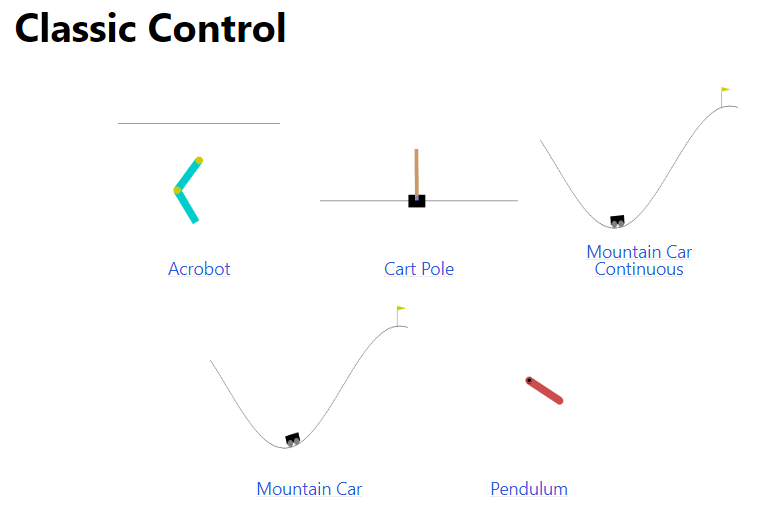   
https://www.gymlibrary.dev/environments/classic_control/

# Visualization

## Classic Control: CartPole

In [3]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3.5]
plt.rcParams["font.size"] = "8"
import warnings
warnings.filterwarnings("ignore")

import gymnasium as gym
gym.__version__  #1.2.0

'1.2.0'

## 기본 process

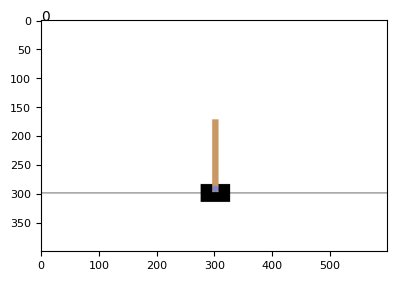

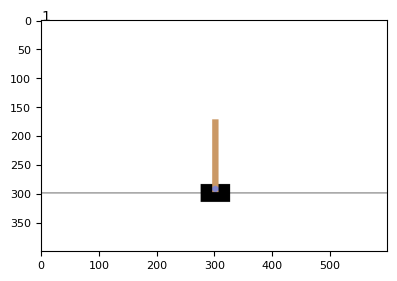

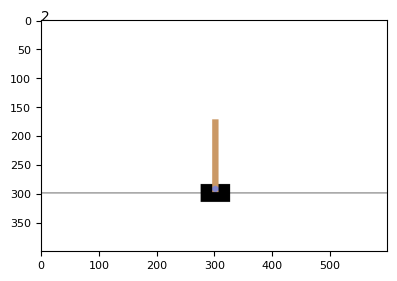

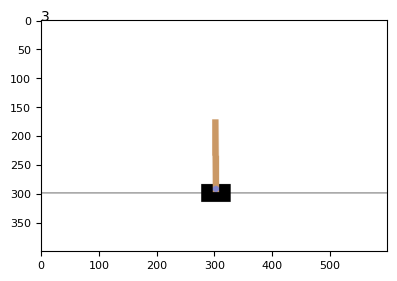

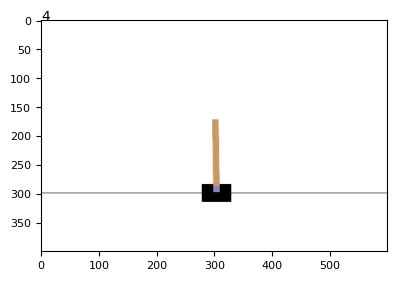

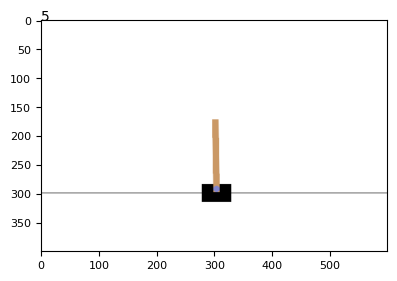

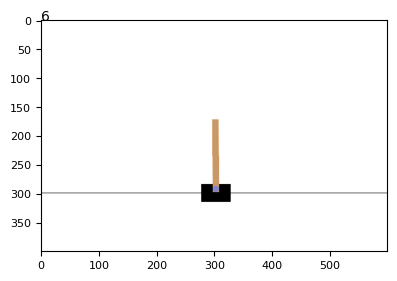

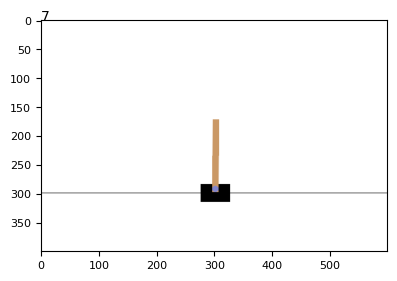

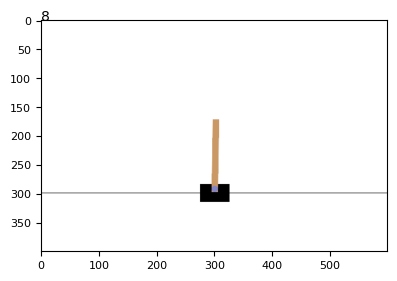

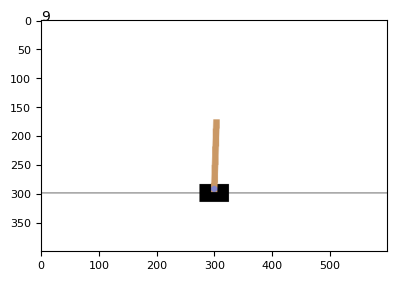

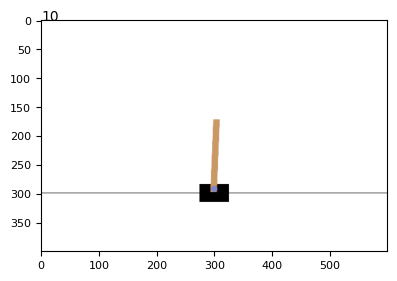

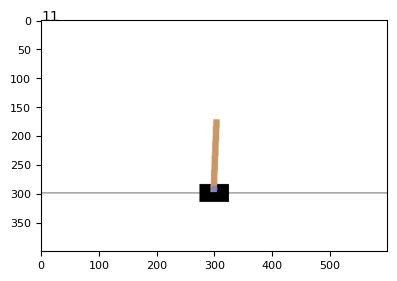

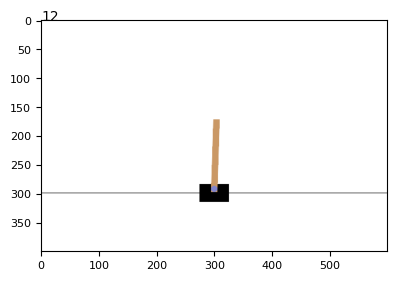

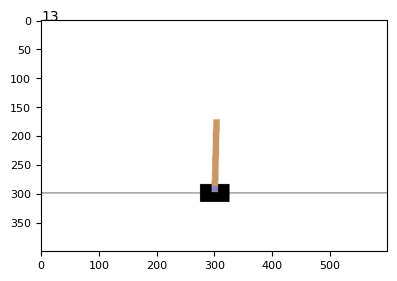

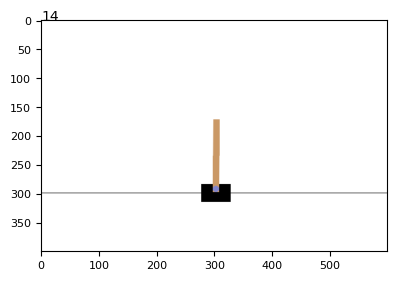

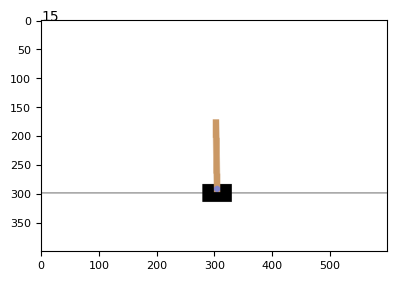

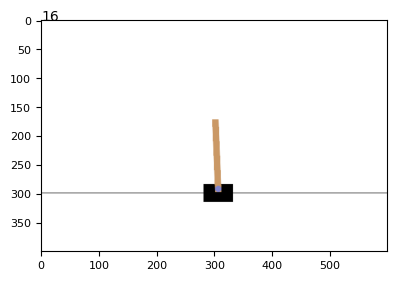

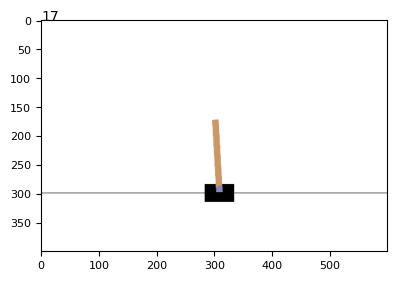

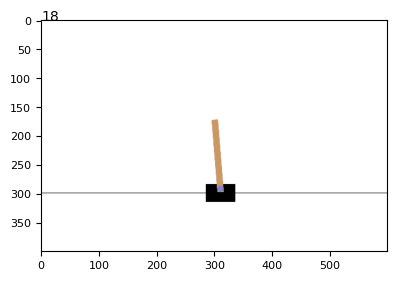

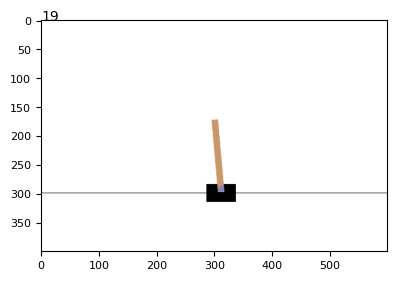

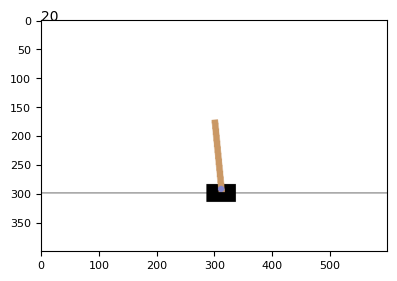

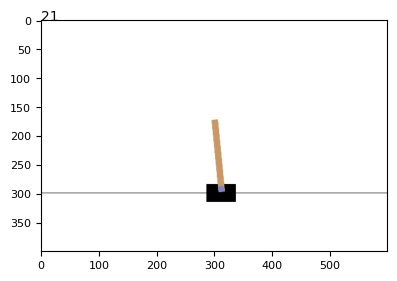

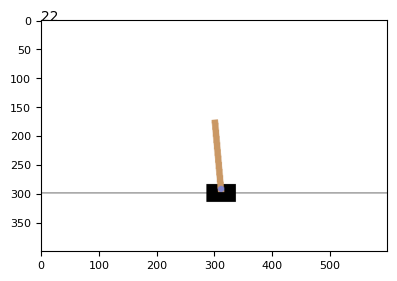

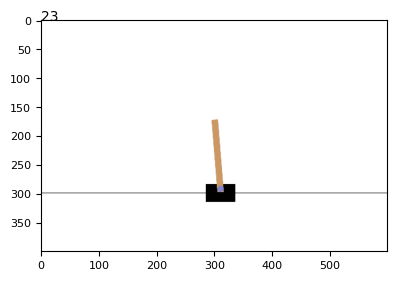

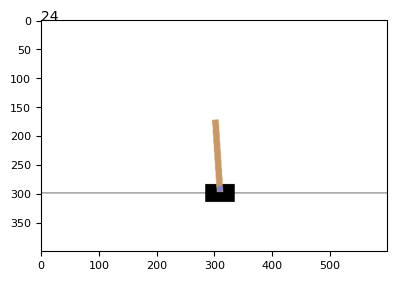

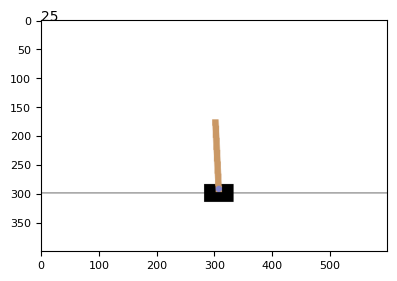

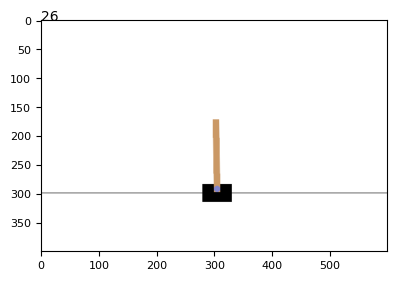

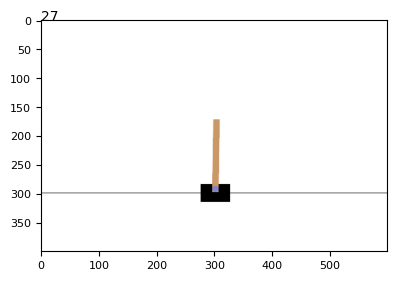

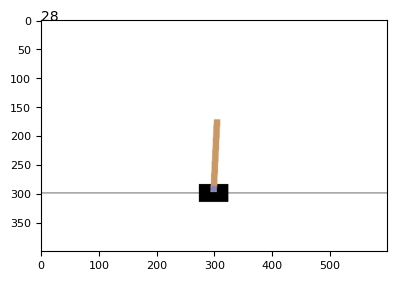

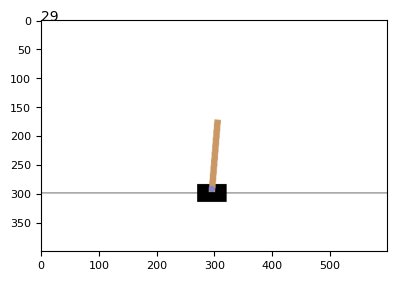

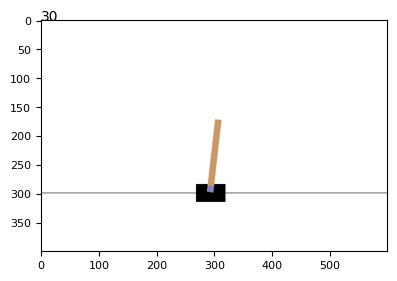

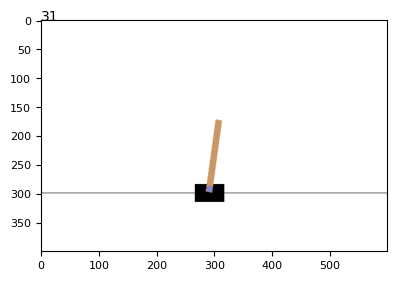

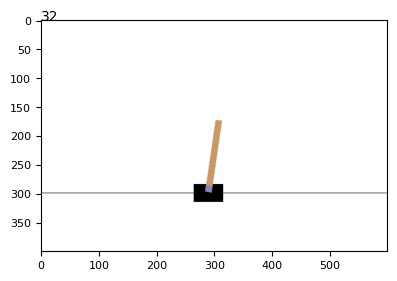

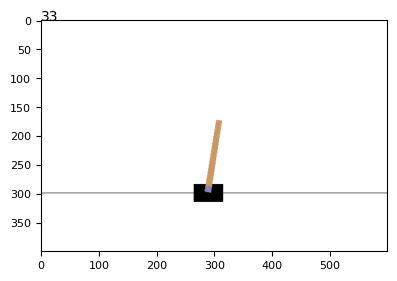

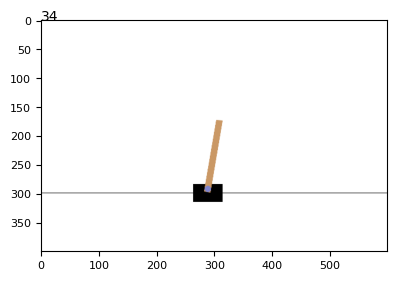

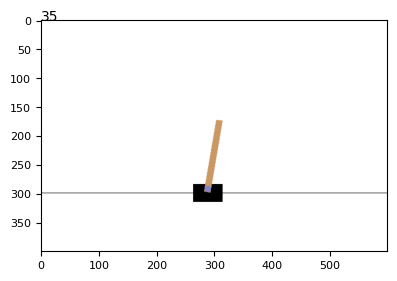

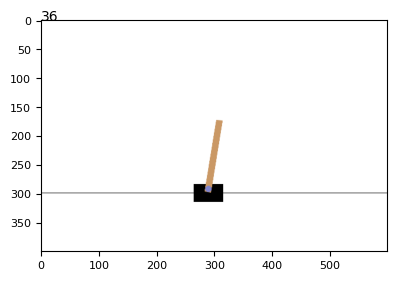

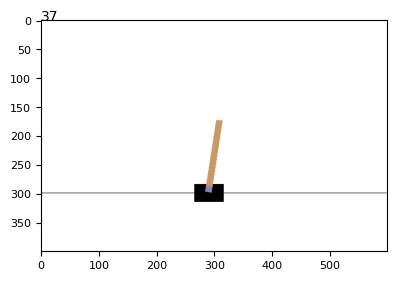

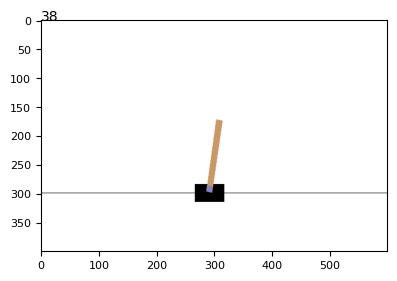

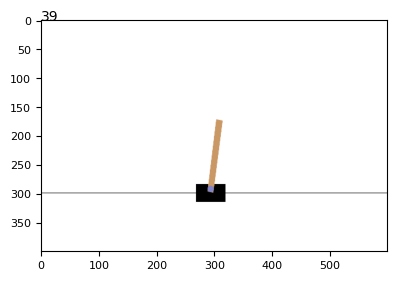

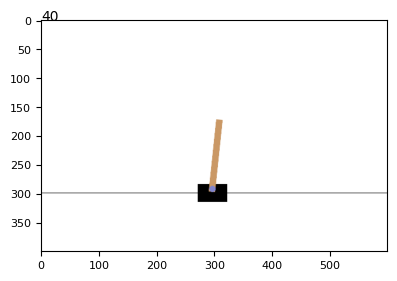

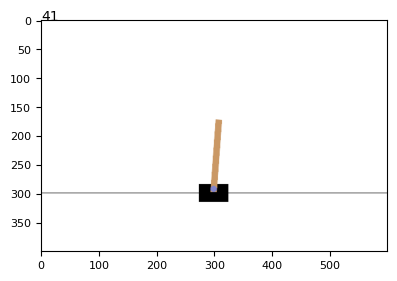

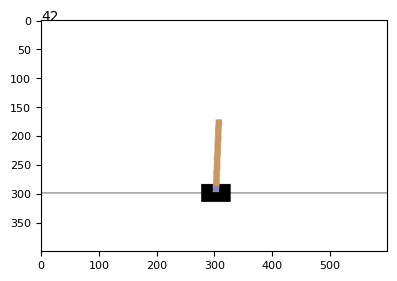

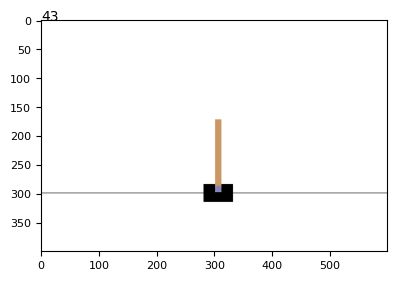

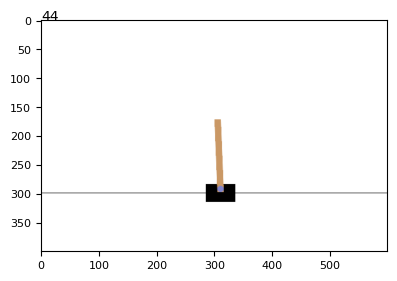

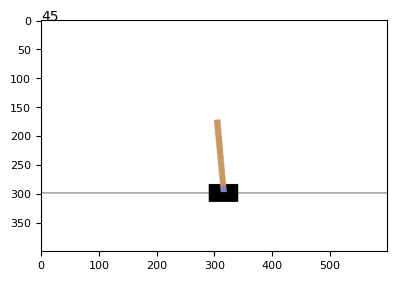

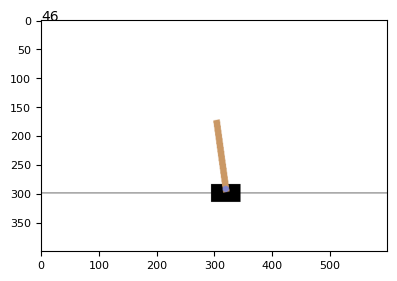

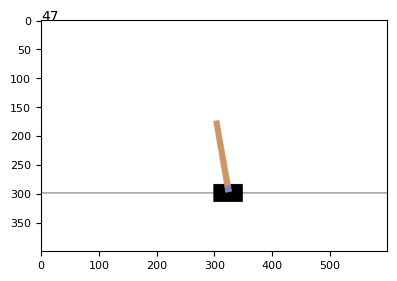

Length[49]:[1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]


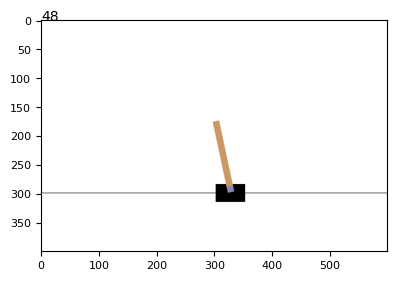

In [4]:
env = gym.make("CartPole-v1", render_mode="rgb_array")

observation,_ = env.reset()
action_l = []
for i in range(500): # while True:
    plt.figure(figsize=(5,3))
    plt.imshow(env.render())
    plt.text(0,0,str(i),fontsize=10)
    ###
    if observation[2] < 0 : # pole angle
      action = 0            # push to the left
    else: action = 1        #        ``   right
    action_l.append(action)
    ###
    observation, reward, done , info, _ = env.step(action)
    if done: break;
    else: plt.show()
env.close()
print(f'Length[{len(action_l)}]:{action_l}')

## 결과 시각화

### Snapshot

```python
import matplotlib.pyplot as plt
from IPython.display import clear_output, display as ipython_display

def render_as_image(env, step=0):
    img = env.render()
    if isinstance(img, list): img = img[0]
    if img.ndim == 4: img = img.squeeze(0)
    plt.imshow(img)
    plt.text(5, 5, f"step: {step}", fontsize=12, color='white',
             bbox=dict(facecolor='black', alpha=0.5))
    plt.axis('off')
    ipython_display(plt.gcf())
    clear_output(wait=True)
```

In [5]:
from render import  render_as_image

In [6]:
def run_cartpole(env,step=500):
    observation, _ = env.reset()
    for i in range(step):
        render_as_image(env,step=i)
        if observation[2] < 0 : # pole angle
          action = 0            # push to the left
        else: action = 1        #        ``   right
        observation, reward, done , info, _ = env.step(action)
        if done: break;
    env.close()

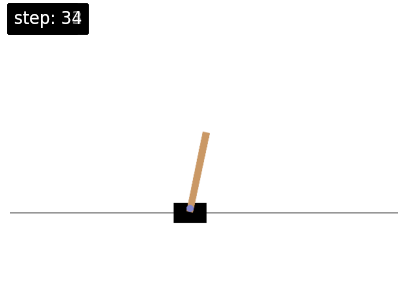

In [7]:
run_cartpole(env,100)

### Video clip

In [8]:
%%time
%%capture
!pip install pyvirtualdisplay
!sudo apt-get update
!sudo apt-get install python-opengl
!sudo apt-get install -f
!sudo apt-get upgrade --fix-missing
!sudo apt-get install xvfb

CPU times: user 3.78 s, sys: 1.91 s, total: 5.69 s
Wall time: 1min


In [10]:
from render import  show_video, wrap_env

In [11]:
from pyvirtualdisplay import Display
display = Display(visible=0, size=(400, 300))
display.start()

```python
from gymnasium.wrappers import RecordVideo  ## Moniter<=0.21.0
def wrap_env(env,path="",name_prefix='cart_pole'):
  env = RecordVideo(env,
                    video_folder=path+'video',
                    video_length=1000,
                    name_prefix=name_prefix)
  return env
```  

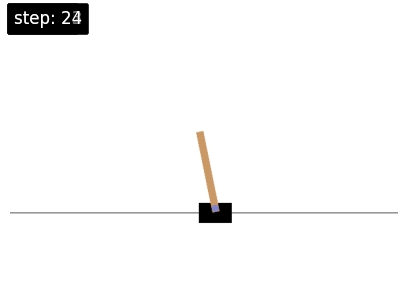

In [12]:
env_v = wrap_env(env)
run_cartpole(env_v)

```python
import glob
import io
import base64
from IPython.display import HTML
from IPython import display as ipythondisplay

def show_video():
  mp4list = glob.glob('video/*.mp4')
  if len(mp4list) > 0:
    mp4 = mp4list[0]
    video = io.open(mp4, 'r+b').read()
    encoded = base64.b64encode(video)
    ipythondisplay.display(HTML(data='''<video alt="test" autoplay
                loop controls style="height: 400px;">
                <source src="data:video/mp4;base64,{0}" type="video/mp4" />
             </video>'''.format(encoded.decode('ascii'))))
  else:
    print("Could not find video")
```    

In [13]:
show_video()

video/cart_pole-episode-0.mp4
